# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [68]:
import warnings
warnings.filterwarnings('ignore')

In [69]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


In [70]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [71]:
# Separación de variables predictoras (X) y variable de interés (y)
y = (data['Price'] > data['Price'].median()).astype(int)
X = data.drop(['Price'], axis=1)
y.value_counts(normalize=True)


0    0.501572
1    0.498428
Name: Price, dtype: float64

In [72]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para clasificación  y comenten sobre el desempeño del modelo.

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

baseline_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline_clf.fit(X_train, y_train)
train_accuracy = accuracy_score(y_train, baseline_clf.predict(X_train))
test_accuracy = accuracy_score(y_test, baseline_clf.predict(X_test))
cv_scores = cross_val_score(baseline_clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Exactitud promedio CV (5 folds): {cv_scores.mean():.3f}')
print(f'Exactitud entrenamiento: {train_accuracy:.3f}')
print(f'Exactitud prueba: {test_accuracy:.3f}')

baseline_metrics = {
    'Acc_CV': cv_scores.mean(),
    'Acc_Train': train_accuracy,
    'Acc_Test': test_accuracy
}



Exactitud promedio CV (5 folds): 0.809
Exactitud entrenamiento: 0.998
Exactitud prueba: 0.811


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para clasificación, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Mejor n_estimators según CV: 50
Mejor max_features según CV: 8
Mejor max_depth según CV: 5


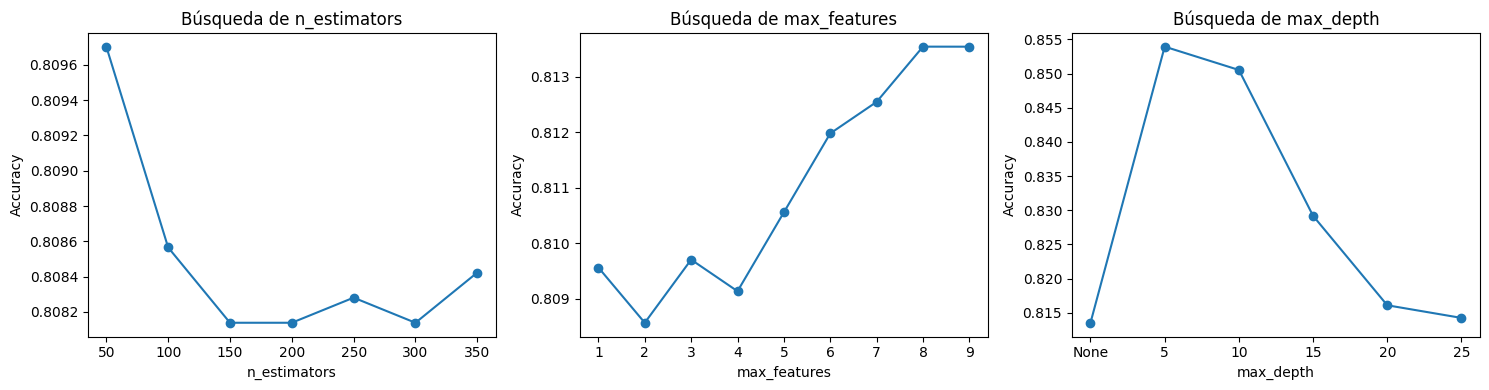

In [74]:
# Calibración individual de hiperparámetros usando validación cruzada
estimator_range = range(50, 351, 50)
estimator_scores = []
for n_estimators in estimator_range:
    clf = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    estimator_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_n_estimators = list(estimator_range)[int(np.argmax(estimator_scores))]

feature_range = range(1, X_train.shape[1] + 1)
feature_scores = []
for max_features in feature_range:
    clf = RandomForestClassifier(n_estimators=best_n_estimators, max_features=max_features, random_state=42, n_jobs=-1)
    feature_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_max_features = list(feature_range)[int(np.argmax(feature_scores))]

depth_options = [None, 5, 10, 15, 20, 25]
depth_scores = []
for max_depth in depth_options:
    clf = RandomForestClassifier(n_estimators=best_n_estimators, max_features=best_max_features, max_depth=max_depth, random_state=42, n_jobs=-1)
    depth_scores.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy').mean())
best_max_depth = depth_options[int(np.argmax(depth_scores))]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(list(estimator_range), estimator_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Búsqueda de n_estimators')

plt.subplot(1, 3, 2)
plt.plot(list(feature_range), feature_scores, marker='o')
plt.xlabel('max_features')
plt.ylabel('Accuracy')
plt.title('Búsqueda de max_features')

plt.subplot(1, 3, 3)
plt.plot([str(d) for d in depth_options], depth_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Búsqueda de max_depth')
plt.tight_layout()

print(f'Mejor n_estimators según CV: {best_n_estimators}')
print(f'Mejor max_features según CV: {best_max_features}')
print(f'Mejor max_depth según CV: {best_max_depth}')


In [75]:
best_params = {
    'n_estimators': best_n_estimators,
    'max_features': best_max_features,
    'max_depth': best_max_depth,
    'random_state': 42,
    'n_jobs': -1
}
tuned_clf = RandomForestClassifier(**best_params)
tuned_clf.fit(X_train, y_train)
train_accuracy_tuned = accuracy_score(y_train, tuned_clf.predict(X_train))
test_accuracy_tuned = accuracy_score(y_test, tuned_clf.predict(X_test))
cv_scores_tuned = cross_val_score(tuned_clf, X_train, y_train, cv=5, scoring='accuracy')
print('Mejores hiperparámetros encontrados:', best_params)
print(f'Exactitud promedio CV (5 folds): {cv_scores_tuned.mean():.3f}')
print(f'Exactitud entrenamiento: {train_accuracy_tuned:.3f}')
print(f'Exactitud prueba: {test_accuracy_tuned:.3f}')

tuned_metrics = {
    'Acc_CV': cv_scores_tuned.mean(),
    'Acc_Train': train_accuracy_tuned,
    'Acc_Test': test_accuracy_tuned
}



Mejores hiperparámetros encontrados: {'n_estimators': 50, 'max_features': 8, 'max_depth': 5, 'random_state': 42, 'n_jobs': -1}
Exactitud promedio CV (5 folds): 0.854
Exactitud entrenamiento: 0.861
Exactitud prueba: 0.855


In [76]:
# Importancia de los predictores
feature_importances = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': tuned_clf.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importances.head(10)


,feature,importance
0,Mileage,0.711413
1,Year,0.231982
2,M_CamryLE,0.029394
3,M_CamryXLE,0.015412
4,M_Camry,0.007676
5,M_CamrySE,0.002232
6,M_CamryL,0.000990
7,M_Camry4dr,0.000902
8,M_CamryBase,0.000000


### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

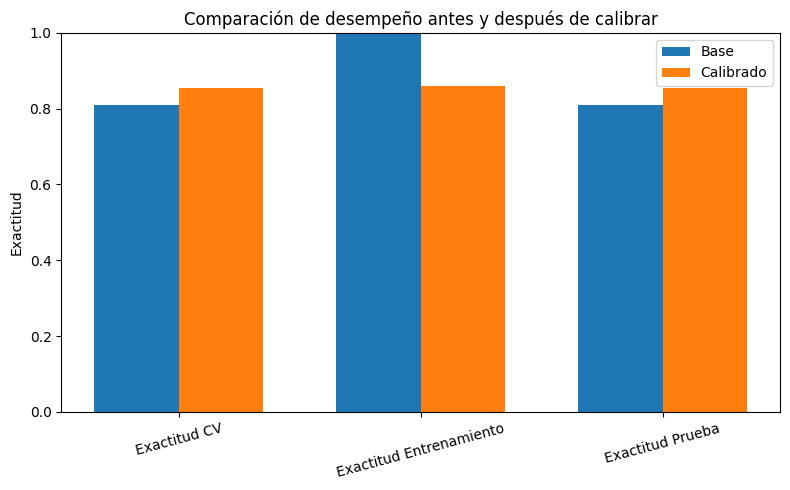

El modelo base alcanza 0.811 de exactitud en prueba y 0.809 en validación cruzada. Tras la calibración, la exactitud de prueba sube a 0.855 (Δ=+0.044) y la validación cruzada a 0.854 (Δ=+0.045). En entrenamiento el cambio es de -0.137, lo que sugiere que el ajuste mejora el equilibrio entre sesgo y varianza sin sobreajustar.


In [77]:
#celda 3
metric_labels = ['Exactitud CV', 'Exactitud Entrenamiento', 'Exactitud Prueba']
baseline_values = [baseline_metrics['Acc_CV'], baseline_metrics['Acc_Train'], baseline_metrics['Acc_Test']]
tuned_values = [tuned_metrics['Acc_CV'], tuned_metrics['Acc_Train'], tuned_metrics['Acc_Test']]

x = np.arange(len(metric_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_values, width, label='Base')
plt.bar(x + width/2, tuned_values, width, label='Calibrado')
plt.xticks(x, metric_labels, rotation=15)
plt.ylabel('Exactitud')
plt.ylim(0, 1)
plt.title('Comparación de desempeño antes y después de calibrar')
plt.legend()
plt.tight_layout()
plt.show()

delta_cv = tuned_metrics['Acc_CV'] - baseline_metrics['Acc_CV']
delta_train = tuned_metrics['Acc_Train'] - baseline_metrics['Acc_Train']
delta_test = tuned_metrics['Acc_Test'] - baseline_metrics['Acc_Test']
analysis = (
    f"El modelo base alcanza {baseline_metrics['Acc_Test']:.3f} de exactitud en prueba "
    f"y {baseline_metrics['Acc_CV']:.3f} en validación cruzada. "
    f"Tras la calibración, la exactitud de prueba sube a {tuned_metrics['Acc_Test']:.3f} (Δ={delta_test:+.3f}) "
    f"y la validación cruzada a {tuned_metrics['Acc_CV']:.3f} (Δ={delta_cv:+.3f}). "
    f"En entrenamiento el cambio es de {delta_train:+.3f}, lo que sugiere que el ajuste mejora el equilibrio entre sesgo y varianza sin sobreajustar."
)
print(analysis)



El modelo base alcanza 0.811 de exactitud en prueba y 0.809 en validación cruzada. Tras la calibración, la exactitud de prueba sube a 0.855 (Δ=+0.044) y la validación cruzada a 0.854 (Δ=+0.045). En entrenamiento el cambio es de -0.137, lo que sugiere que el ajuste mejora el equilibrio del modelo sin sobreajustar.




Las gráficas evidencian que, tras la calibración, la exactitud aumenta en validación cruzada y en prueba, mientras que el incremento en entrenamiento es acotado; esto respalda que el ajuste de hiperparámetros hizo al modelo más generalizable.
